In [1]:
import pandas as pd
data={
    'Height':[170,172,168,190,192,188],
    'Weight':[65,67,63,95,98,92]

}
data=pd.DataFrame(data)
print(data)

   Height  Weight
0     170      65
1     172      67
2     168      63
3     190      95
4     192      98
5     188      92


<Axes: xlabel='Height', ylabel='Weight'>

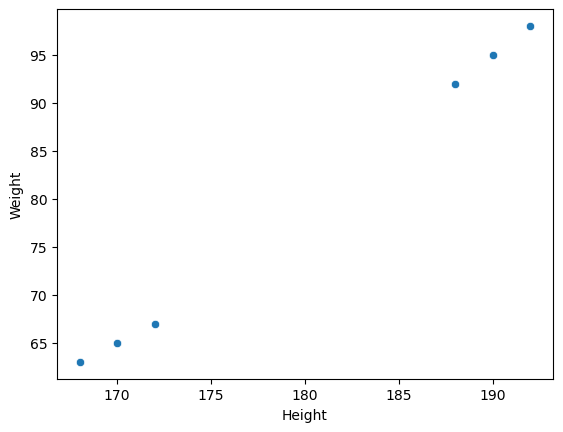

In [ ]:

import seaborn as sns
sns.scatterplot(x='Height',y='Weight',data=data)

In [4]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data)
scaled_data=pd.DataFrame(scaled_data,columns=data.columns)
print(scaled_data)

     Height    Weight
0 -0.986928 -0.990507
1 -0.789542 -0.858440
2 -1.184313 -1.122575
3  0.986928  0.990507
4  1.184313  1.188609
5  0.789542  0.792406


In [8]:
#apply model
from sklearn.cluster import AgglomerativeClustering as HierarchicalClustering
model=HierarchicalClustering(n_clusters=2)
model.fit(scaled_data)
data['Cluster']=model.labels_
print(data)


   Height  Weight  Cluster
0     170      65        1
1     172      67        1
2     168      63        1
3     190      95        0
4     192      98        0
5     188      92        0


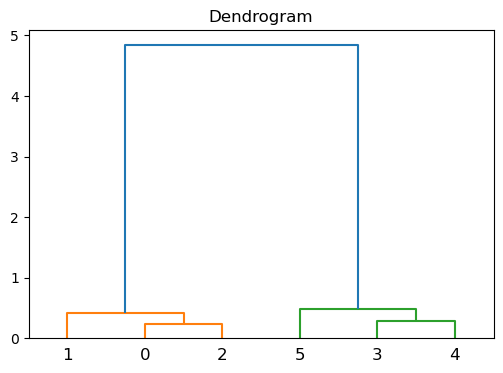

In [10]:
from scipy.cluster.hierarchy import dendrogram,linkage
import matplotlib.pyplot as plt

linked=linkage(scaled_data,method='ward')

plt.figure(figsize=(6, 4))
dendrogram(linked)
plt.title('Dendrogram')
plt.show()

In [11]:
#Integrate FAST API in streamlit
import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save model
joblib.dump(model, "model.pkl")


['model.pkl']